## Goal and how to run

Download the complete `.ipynb`. In VibeIt Studio's file browser use **+ → Import from Files**, then open it. Run code cells from top to bottom. Saved charts show actual executed results; rerunning recomputes them from embedded data.

This lesson assumes basic Python knowledge. Read each method and caption before changing parameters. AI exercises are optional; no AI account is needed for the core workflow. Data lives in notebook metadata, so there is no companion data download. Keep the notebook saved in the active working folder.

Your goal is to understand the research question, execute transparent calculations, check the results, and state the limits of the conclusion.

## Setup and parameters

In [1]:
from pathlib import Path
import base64, gzip, hashlib, json, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from scipy.optimize import brentq
from IPython.display import display as _display
def display(value):
    if isinstance(value,pd.DataFrame):
        table=value.to_html(max_rows=12,escape=True)
        style="<style>.vibeit-readable-table{max-width:100%;overflow-x:auto}.vibeit-readable-table table{width:max-content;max-width:none;border-collapse:collapse}.vibeit-readable-table td,.vibeit-readable-table th{white-space:nowrap!important;word-break:normal!important;overflow-wrap:normal!important}</style>"
        return _display(HTML(style+'<div class="vibeit-readable-table">'+table+'</div>'))
    return _display(value)
RECIPE_ID='ma02-bracketed-roots'
OUTPUT_DIR=Path.cwd()/"results"/RECIPE_ID
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                      "axes.prop_cycle":plt.cycler(color=["#18785f","#416aa6","#bc6541","#9974a5"])})
print("Python:",platform.python_version(),"; NumPy:",np.__version__,"; Pandas:",pd.__version__)
print("Working folder:",Path.cwd())
print("Core data mode: embedded snapshot; no network requests")


Python: 3.13.13 ; NumPy: 2.5.3 ; Pandas: 3.0.6
Working folder: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads
Core data mode: embedded snapshot; no network requests


### Load the embedded snapshot

The loader locates this notebook in the working folder by recipe ID and SHA-256, then decompresses and verifies the data. Renaming the file does not change its identity. If loading fails, check the working folder and saved file. Metadata travels with `.ipynb` save/export; copying code to a standalone `.py` does not copy the dataset.

In [2]:
def load_snapshot(recipe_id, expected_sha256, snapshot_key):
    """Read embedded data from this notebook, including a renamed copy."""
    for path in sorted(Path.cwd().glob("*.ipynb")):
        try:
            notebook = json.loads(path.read_text(encoding="utf-8"))
            metadata = notebook.get("metadata", {}).get("vibeit_cookbook", {})
            blob = metadata.get("snapshots", {}).get(snapshot_key)
            if metadata.get("recipe_id") != recipe_id or not blob:
                continue
            if blob.get("sha256") != expected_sha256:
                continue
            raw = gzip.decompress(base64.b64decode(blob["gzip_base64"], validate=True))
            if hashlib.sha256(raw).hexdigest() != expected_sha256:
                raise ValueError("Embedded snapshot checksum mismatch: " + snapshot_key)
            return json.loads(raw)
        except (OSError, json.JSONDecodeError):
            continue
    raise FileNotFoundError(
        "Save/open the complete .ipynb in the active working folder. "
        "The embedded snapshot could not be located for " + recipe_id)

SNAPSHOT_HASHES={'constants': '2533802a1a546c612d06ba2e931e4f32a418be854c75a5e9c327ff57d5b56126'}
def snapshot(key):
    return load_snapshot(RECIPE_ID,SNAPSHOT_HASHES[key],key)
print("Embedded snapshots:",list(SNAPSHOT_HASHES))


Embedded snapshots: ['constants']


### Read the method functions

The full implementations appear below. They use the listed bundled packages and standard library; no cookbook helper module is imported at runtime. Inspect input requirements and return values. If you change an algorithm, its checks must still pass.

In [3]:
def bisection(function,lower,upper,tolerance=1e-10,max_iterations=100):
    """Bracket a continuous scalar root; retain each actual interval update."""
    if not np.isfinite([lower,upper,tolerance]).all() or lower>=upper or tolerance<=0:raise ValueError('Invalid bracket or tolerance')
    f_lower=float(function(lower));f_upper=float(function(upper))
    if not np.isfinite([f_lower,f_upper]).all():raise ValueError('Non-finite endpoint values')
    if f_lower==0:return lower,[]
    if f_upper==0:return upper,[]
    if np.sign(f_lower)==np.sign(f_upper):raise ValueError('The bracket does not change sign')
    history=[]
    for iteration in range(max_iterations):
        midpoint=(lower+upper)/2;value=float(function(midpoint))
        if not np.isfinite(value):raise ValueError('Non-finite function value')
        history.append([iteration,lower,upper,midpoint,value,upper-lower])
        if value==0 or (upper-lower)/2<=tolerance:return midpoint,history
        if np.sign(value)==np.sign(f_lower):lower=midpoint;f_lower=value
        else:upper=midpoint;f_upper=value
    raise RuntimeError('Requested root tolerance not reached')

print("Method ready: bisection")


Method ready: bisection


### Data and model boundary

Analytic functions and Monte Carlo points are mathematical teaching models, not experimental measurements. When Iris observations are used, row exchangeability and the sampling design remain assumptions; convenience records alone do not establish population representativeness. Numerical discretization error is distinct from sampling uncertainty.

## Steps

### 1. Exclude the trivial root

The wavelength form of Planck’s law gives 5(1−exp(−x))−x=0. x=0 is a mathematical root but not the positive spectral maximum sought here. The bracket [1,10] has a sign change and isolates the relevant positive root.

Positive root: 4.9651142317961785 ; independent brentq: 4.965114231744276


,iteration,lower,upper,midpoint,f_midpoint,width
0,0,1.0000,10.000000,5.500000,-0.520434,9.000000
1,1,1.0000,5.500000,3.250000,1.556129,4.500000
2,2,3.2500,5.500000,4.375000,0.562059,2.250000
3,3,4.3750,5.500000,4.937500,0.026637,1.125000
4,4,4.9375,5.500000,5.218750,-0.245820,0.562500
5,5,4.9375,5.218750,5.078125,-0.109283,0.281250
6,6,4.9375,5.078125,5.007812,-0.041240,0.140625
7,7,4.9375,5.007812,4.972656,-0.007280,0.070312


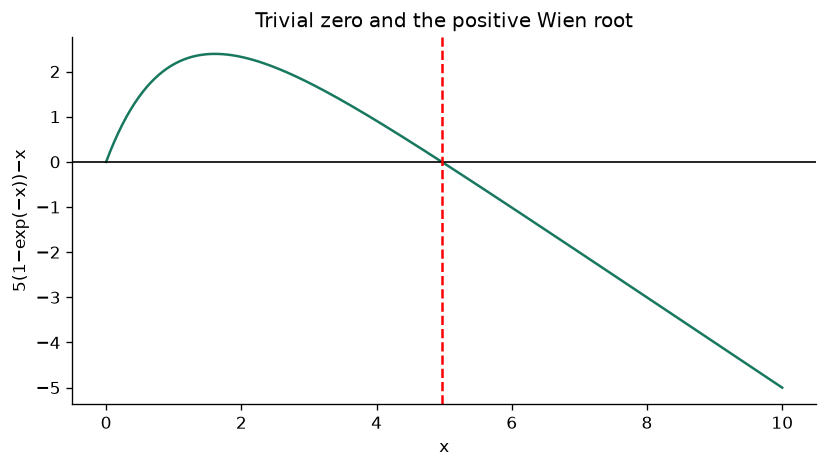

In [4]:
constants=snapshot("constants")["constants"]
def equation(value):return 5*(-np.expm1(-value))-value
root,history=bisection(equation,1.0,10.0,tolerance=1e-10)
reference=brentq(equation,1.0,10.0,xtol=1e-13)
trace=pd.DataFrame(history,columns=["iteration","lower","upper","midpoint","f_midpoint","width"])
print("Positive root:",root,"; independent brentq:",reference)
display(trace.head(8))
grid=np.linspace(0,10,501)
fig,ax=plt.subplots(figsize=(7,4));ax.plot(grid,equation(grid));ax.axhline(0,color="black",lw=1);ax.axvline(root,color="red",linestyle="--")
ax.set(xlabel="x",ylabel="5(1−exp(−x))−x",title="Trivial zero and the positive Wien root");plt.tight_layout();plt.show()


### 2. Inspect the bracket certificate

Every iteration retains an interval with opposite endpoint signs. Width shrinks by a factor of two. The stopping rule bounds midpoint location error by half the current interval width; a small residual alone does not guarantee the same coordinate error for a flat function.

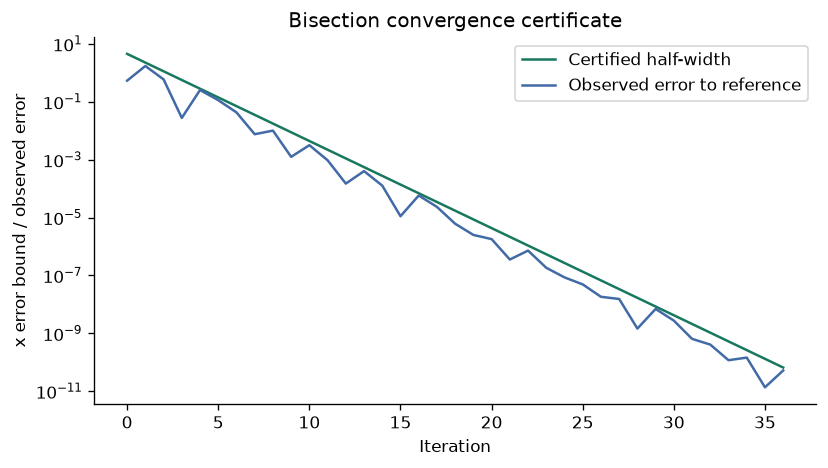

In [5]:
fig,ax=plt.subplots(figsize=(7,4));ax.semilogy(trace.iteration,trace.width/2,label="Certified half-width")
ax.semilogy(trace.iteration,np.maximum(np.abs(trace.midpoint-reference),1e-16),label="Observed error to reference")
ax.set(xlabel="Iteration",ylabel="x error bound / observed error",title="Bisection convergence certificate");ax.legend();plt.tight_layout();plt.show()


### 3. Convert the dimensionless root into physical units

Using frozen h, c and k_B, b=hc/(k_B x) has units metre·kelvin. The curve shows predicted peak wavelength in nm at each assumed blackbody temperature in K. These are ideal-model values, not measured stellar spectra.

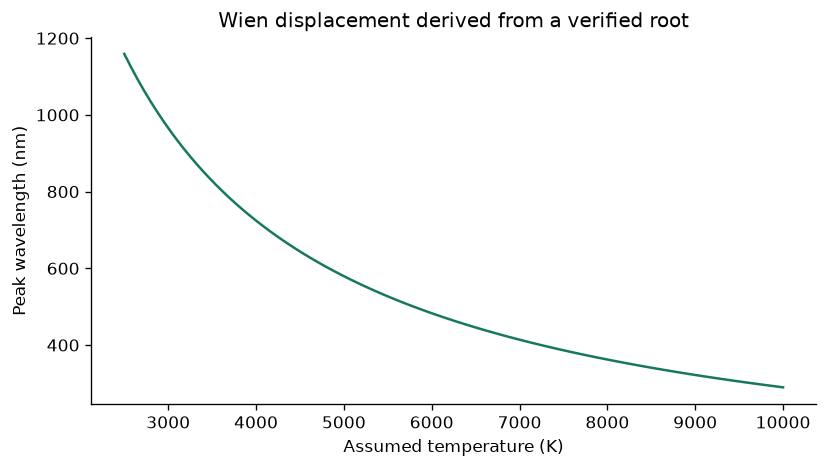

Derived displacement constant (m K): 0.002897771955154881


In [6]:
b=constants["h"]["value"]*constants["c"]["value"]/(constants["k_B"]["value"]*root)
temperatures=np.linspace(2500,10000,101);peak_nm=1e9*b/temperatures
fig,ax=plt.subplots(figsize=(7,4));ax.plot(temperatures,peak_nm)
ax.set(xlabel="Assumed temperature (K)",ylabel="Peak wavelength (nm)",title="Wien displacement derived from a verified root");plt.tight_layout();plt.show()
print("Derived displacement constant (m K):",b)


### 4. Check signs, tolerances and exported units

Compare the returned root with the independent solver and check every recorded bracket. A non-bracketing interval must raise an error. A numerical tolerance is a computation setting, not an experimental measurement uncertainty.

In [7]:
assert abs(root-reference)<=trace.width.iloc[-1]/2+1e-12
assert all(equation(lo)*equation(hi)<=0 for lo,hi in zip(trace.lower,trace.upper))
assert np.isclose(b,2.897771955e-3,rtol=1e-8)
try:bisection(equation,6,10)
except ValueError:print("Non-bracketing interval rejected")
else:raise AssertionError("Missing sign change accepted")
OUTPUT_DIR.mkdir(parents=True,exist_ok=True);trace.to_csv(OUTPUT_DIR/"bisection-trace.csv",index=False)
pd.DataFrame({"temperature_K":temperatures,"peak_wavelength_nm":peak_nm}).to_csv(OUTPUT_DIR/"wien-curve.csv",index=False)
print("Root certificate and unit checks passed; exports:",OUTPUT_DIR)


Non-bracketing interval rejected
Root certificate and unit checks passed; exports: /Users/zhiluo/Developer/vibeit-cookbook/cookbook/downloads/results/ma02-bracketed-roots


## Exercises and reference explanation

1. Why is x=0 excluded from the Wien maximum search?
2. What does halving the bracket certify?

**Reference explanation.** The trivial root is not the positive interior spectral maximum. Half-width bounds midpoint coordinate error for the retained continuous-function bracket.

Keep a copy before changing parameters. Compare old and new figures and record which inputs, calculations and conclusions changed.

## Optional AI coding exercises

Open the current notebook in VibeIt's Coding Agent and ask it to read the relevant cells. The core lesson does not depend on AI access; see the Help Center for provider and account setup.

**Prompt 1**

> Using NumPy/SciPy/Matplotlib, compare tolerances 1e-6, 1e-8 and 1e-10 and preserve every bracket certificate.

**Prompt 2**

> Using the same packages, annotate predicted peak wavelengths at 3000, 5000 and 8000 K with units.

**Human acceptance.** Every retained bracket changes sign, roots agree with brentq within half-width and wavelengths are positive.

Review the edited source, then manually run affected cells and subsequent checks. Ask the assistant to explain the purpose, packages and data provenance of its changes, and reconcile that explanation with actual output.

## Optional online extension

The network action below is disabled by default. It reports a database version/source without replacing the core data. To refresh data, save a separate experimental version and record the new URL, database release, retrieval date and SHA-256. New results require rerunning and validation.

In [8]:
RUN_ONLINE_UPDATE=False
if RUN_ONLINE_UPDATE:
    import requests
    try:
        response=requests.get('https://physics.nist.gov/cuu/Constants/',timeout=20)
        response.raise_for_status()
        print("Source:",response.url)
        print(response.text[:700])
    except requests.RequestException as error:
        print("Online extension unavailable:",type(error).__name__,str(error)[:160])
else:
    print("Online extension skipped; embedded core data unchanged")


Online extension skipped; embedded core data unchanged


## Sources, snapshots and next steps

- [NIST CODATA physical constants](https://physics.nist.gov/cuu/Constants/Table/allascii.txt) — NIST public reference data; credit NIST/CODATA; retrieved 2026-10-09. SHA-256 `77fb90e66c40db3e6eb16630bc9c88e4c7c8beddbe5e71be406f2f26e3f67e67`.
  Preserve official ASCII table; extract seven explicitly named SI constants and their units.


**Next steps.** Transfer these methods to your own public or authorized data while retaining input checks, recorded parameters and result validation. Document the new experimental design and method limits; this example does not validate a new experiment. Full data licenses and generation instructions accompany the cookbook.